# Dataset inspection

What the patching experiments will actually load, and why each file exists.

The data pipeline has three stages whose filenames deliberately name the same
dataset at different points, which is exactly what makes it easy to lose track
of which one matters:

| stage | contents | used by experiments? |
|---|---|---|
| `data/raw/` | original source files, untouched | no |
| `*_curated.json` | full dataset, prompts rendered, no sampling | no |
| **`*_candidates.json`** | **balanced pool the experiments read** | **yes** |

The filename is never hardcoded below. It is read from `src.tasks.TASKS`, the
same lookup `run_patchings.py` and `run_ablations.py` use, so this notebook
cannot drift from what the drivers load.

In [1]:
import json, os, sys, textwrap
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

REPO = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, REPO)
PROCESSED = os.path.join(REPO, "data", "processed")

from src.tasks import TASKS, get_task
from src.templates import TEMPLATES, DEFAULT_TEMPLATE, get_template
from src.models import MODELS

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 200)

print("repo:", REPO)
print("tasks    :", sorted(TASKS))
print("templates:", sorted(TEMPLATES), " (default:", DEFAULT_TEMPLATE + ")")
print("models   :", sorted(MODELS))

repo: c:\Users\srkno\Desktop\CoT_Mechanistic_Interpretability
tasks    : ['prontoqa', 'svamp']
templates: ['qa1shot', 'step_by_step']  (default: step_by_step)
models   : ['llama3.2-1b', 'olmo2-1b', 'qwen2.5-0.5b']


## 1. Which file does each experiment load?

In [2]:
rows = []
for key, task in TASKS.items():
    path = os.path.join(PROCESSED, task.dataset_file)
    exists = os.path.exists(path)
    rows.append({
        "--dataset": key,
        "file": task.dataset_file,
        "exists": exists,
        "examples": len(json.load(open(path, encoding="utf-8"))) if exists else 0,
        "size (KB)": round(os.path.getsize(path) / 1024) if exists else 0,
        "id column": task.id_column,
        "answer column": task.answer_column,
        "stratified by": ", ".join(task.stratify_keys),
    })
pd.DataFrame(rows).set_index("--dataset")

,file,exists,examples,size (KB),id column,answer column,stratified by
--dataset,,,,,,,
svamp,svamp_candidates.json,True,104,241,ID,Answer,"OperationCount, Type"
prontoqa,prontoqa_candidates.json,True,100,513,ID,Answer,hop


### Everything else in `data/processed/`

Anything not listed above is an intermediate or a leftover, and no experiment
reads it.

In [3]:
loaded = {t.dataset_file for t in TASKS.values()}
notes = {
    "svamp_curated.json": "intermediate: all 1000 SVAMP rows with prompts rendered, before sampling",
    "prontoqa_curated.json": "intermediate: all 200 generated ProntoQA rows, before hop filtering",
    "svamp_curated_subset.json": "LEGACY: the 32 examples behind 'results/Old results/'; old flat column names",
}
rows = []
for f in sorted(os.listdir(PROCESSED)):
    if not f.endswith(".json"):
        continue
    rows.append({
        "file": f,
        "role": "LOADED BY EXPERIMENTS" if f in loaded else "not used",
        "size (KB)": round(os.path.getsize(os.path.join(PROCESSED, f)) / 1024),
        "note": notes.get(f, ""),
    })
pd.DataFrame(rows).set_index("file")

,role,size (KB),note
file,,,
prontoqa_candidates.json,LOADED BY EXPERIMENTS,513,
prontoqa_curated.json,not used,982,"intermediate: all 200 generated ProntoQA rows, before hop filtering"
svamp_candidates.json,LOADED BY EXPERIMENTS,241,
svamp_curated.json,not used,2313,"intermediate: all 1000 SVAMP rows with prompts rendered, before sampling"


## 2. Load the two candidate pools

In [4]:
data = {}
for key, task in TASKS.items():
    path = os.path.join(PROCESSED, task.dataset_file)
    if os.path.exists(path):
        data[key] = pd.read_json(path)
        print(f"{key:10s} {len(data[key]):4d} rows   {len(data[key].columns)} columns")
    else:
        print(f"{key:10s} MISSING -- run: python prepare_dataset.py")

svamp       104 rows   12 columns
prontoqa    100 rows   9 columns


In [5]:
for key, df in data.items():
    print(f"--- {key} ---")
    print(list(df.columns))
    print()

--- svamp ---
['ID', 'Body', 'Question', 'Equation', 'Answer', 'Type', 'OperationCount', 'PromptWithoutExample', 'PromptWithCot__step_by_step', 'PromptWithoutCot__step_by_step', 'PromptWithCot__qa1shot', 'PromptWithoutCot__qa1shot']

--- prontoqa ---
['ID', 'hop', 'PromptWithoutExample', 'Answer', 'ChainOfThought', 'PromptWithCot__step_by_step', 'PromptWithoutCot__step_by_step', 'PromptWithCot__qa1shot', 'PromptWithoutCot__qa1shot']



## 3. Balance

The pools are deliberately larger than the target of 100. The pre-filter drops
any example whose CoT trace never reaches the answer anchor, and that decision
is model-dependent, so the final set is the intersection across all three
models. Over-sampling keeps n=100 reachable.

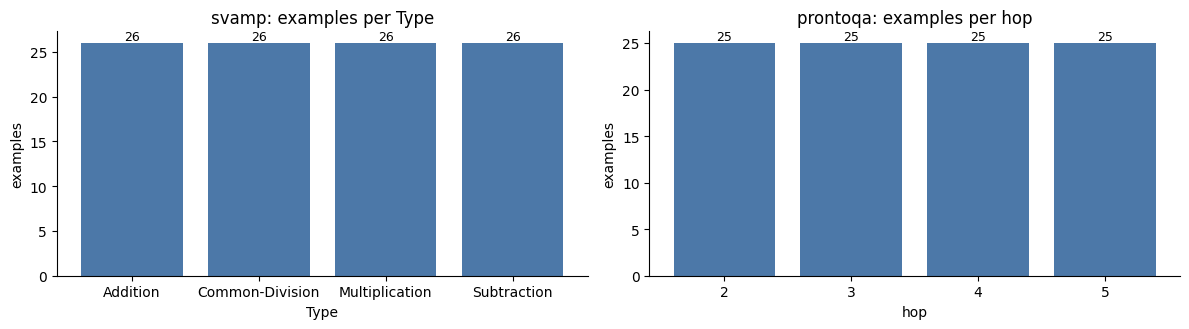

In [6]:
fig, axes = plt.subplots(1, len(data), figsize=(6 * len(data), 3.4))
axes = [axes] if len(data) == 1 else axes

for ax, (key, df) in zip(axes, data.items()):
    task = get_task(key)
    grp = task.stratify_keys[-1]
    counts = df[grp].value_counts().sort_index()
    ax.bar([str(i) for i in counts.index], counts.values, color="#4C78A8")
    ax.set_title(f"{key}: examples per {grp}")
    ax.set_xlabel(grp)
    ax.set_ylabel("examples")
    for i, v in enumerate(counts.values):
        ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

In [7]:
for key, df in data.items():
    task = get_task(key)
    print(f"=== {key} ===")
    print("  answer distribution:", dict(Counter(df[task.answer_column].astype(str)).most_common(6)))
    for grp in task.stratify_keys:
        print(f"  by {grp}: {df[grp].value_counts().sort_index().to_dict()}")
    print()

=== svamp ===
  answer distribution: {'2': 9, '1': 7, '5': 6, '22': 5, '3': 5, '13': 3}
  by OperationCount: {1: 52, 2: 52}
  by Type: {'Addition': 26, 'Common-Division': 26, 'Multiplication': 26, 'Subtraction': 26}

=== prontoqa ===
  answer distribution: {'True': 50, 'False': 50}
  by hop: {2: 25, 3: 25, 4: 25, 5: 25}



## 4. The prompt pair

Every patching run is a clean/corrupted pair:

- **clean** = the CoT prompt, carrying the `Let's think step by step.` cue
- **corrupted** = the No-CoT prompt plus the answer trigger

The cue appears **only** on the CoT side. That asymmetry is the manipulation,
and it is the one thing that must not leak across.

In [8]:
tpl = get_template(DEFAULT_TEMPLATE)
print("template     :", tpl.key)
print("description  :", tpl.description)
print("CoT column   :", tpl.cot_col)
print("No-CoT column:", tpl.nocot_col)
print("corrupt suffix:", repr(tpl.corrupt_suffix))

template     : step_by_step
description  : 1-shot with an explicit 'Let's think step by step.' cue on the CoT side
CoT column   : PromptWithCot__step_by_step
No-CoT column: PromptWithoutCot__step_by_step
corrupt suffix: ' The answer is '


In [9]:
def show(key, i=0, width=100):
    task, df = get_task(key), data[key]
    row = df.iloc[i]
    print("=" * width)
    print(f"{key}   id={row[task.id_column]!r}   gold={row[task.answer_column]!r}")
    print("=" * width)
    for label, text in [
        ("CLEAN  (CoT prompt)", row[tpl.cot_col]),
        ("CORRUPTED  (No-CoT prompt + trigger)", row[tpl.nocot_col] + tpl.corrupt_suffix),
    ]:
        print(f"\n{label}:")
        print(textwrap.fill(text, width, initial_indent="   ", subsequent_indent="   "))
    print()

for key in data:
    show(key, 0)

svamp   id='chal-961'   gold=92

CLEAN  (CoT prompt):
   Q: Roger has 5 tennis balls. He buys 2 more cans of tennis balls. Each can has 3 tennis balls.
   How many tennis balls does he have now? A: Let's think step by step. Roger started with 5 balls.
   Each can has 3 balls, so total balls from cans = 2 * 3 = 6. Then total = 5 + 6 = 11. The answer
   is 11. Q: Katie had 84 new games and 19 old games. Her friends had 8 new games and 69 old games.
   How many new games do they have together? A: Let's think step by step.

CORRUPTED  (No-CoT prompt + trigger):
   Q: Julia played tag with 13 kids on monday and 10 kids on tuesday. She played cards with 15 kids
   on wednesday. How many kids did she play with altogether? A: The answer is 38.0. Q: Katie had 84
   new games and 19 old games. Her friends had 8 new games and 69 old games. How many new games do
   they have together? A: The answer is

prontoqa   id='2hop-example20'   gold='True'

CLEAN  (CoT prompt):
   Q: Sterpuses are snowy. St

### Invariants

Four properties every row must satisfy. A violation here would corrupt the
experiment silently, so they are asserted rather than eyeballed:

1. the CoT prompt contains the answer trigger exactly once (the demonstration's)
2. the corrupted prompt ends with the trigger — that is the patch site
3. the CoT cue never leaks into the No-CoT side
4. the prompts match what `run_patchings.py` builds, byte for byte

In [10]:
from src.templates import ANSWER_TRIGGER, STEP_BY_STEP
from src.templates import make_cot_prompt_from_row, make_nocot_prompt_from_row

rows = []
for key, df in data.items():
    task = get_task(key)
    n = len(df)
    trigger_once = sum(r[tpl.cot_col].count(ANSWER_TRIGGER) == 1 for _, r in df.iterrows())
    ends_trigger = sum((r[tpl.nocot_col] + tpl.corrupt_suffix).endswith(ANSWER_TRIGGER)
                       for _, r in df.iterrows())
    no_leak = sum(STEP_BY_STEP not in r[tpl.nocot_col] for _, r in df.iterrows())
    # the ablation builds its prompts through utils; they must agree with the driver
    same = sum(
        make_cot_prompt_from_row(r, template=tpl) == r[tpl.cot_col]
        and make_nocot_prompt_from_row(r, template=tpl, task=task) == r[tpl.nocot_col] + tpl.corrupt_suffix
        for _, r in df.iterrows())
    rows.append({"dataset": key, "n": n,
                 "trigger appears once": f"{trigger_once}/{n}",
                 "corrupted ends w/ trigger": f"{ends_trigger}/{n}",
                 "no cue leak into No-CoT": f"{no_leak}/{n}",
                 "ablation == patching prompt": f"{same}/{n}"})
    assert trigger_once == ends_trigger == no_leak == same == n, f"invariant violated in {key}"

print("all invariants hold\n")
pd.DataFrame(rows).set_index("dataset")

all invariants hold



,n,trigger appears once,corrupted ends w/ trigger,no cue leak into No-CoT,ablation == patching prompt
dataset,,,,,
svamp,104,104/104,104/104,104/104,104/104
prontoqa,100,100/100,100/100,100/100,100/100


## 5. Answer handling

Arithmetic and True/False need different parsing, different comparison, and a
different rule for which tokens still belong to the answer while generating.
`src/tasks.py` owns all three.

The round trip below feeds each gold answer back through the task's own parser
and comparator — if it does not recover the label, scoring is broken.

In [11]:
rows = []
for key, df in data.items():
    task = get_task(key)
    ok = sum(task.is_correct(f"...{ANSWER_TRIGGER}{g}", g)
             for g in df[task.answer_column])
    rows.append({"dataset": key, "parser": task.parse_answer.__name__,
                 "comparator": task.answers_equal.__name__,
                 "continuation gate": task.is_answer_continuation.__name__,
                 "round trip": f"{ok}/{len(df)}"})
    assert ok == len(df), f"answer round trip failed for {key}"
pd.DataFrame(rows).set_index("dataset")

,parser,comparator,continuation gate,round trip
dataset,,,,
svamp,extract_last_number,numeric_equal,numeric_continuation,104/104
prontoqa,extract_first_bool,bool_equal,alpha_continuation,100/100


In [12]:
# which generated tokens are still treated as part of the answer
probe = ["9", "2", " 38", ".", "-", "True", " Tr", "ue", " Therefore", "\n", " ", "apples"]
pd.DataFrame(
    {key: {repr(t): get_task(key).is_answer_continuation(t) for t in probe} for key in data}
).rename_axis("token")

,svamp,prontoqa
token,,
'9',True,False
'2',True,False
' 38',True,False
'.',True,False
'-',True,False
'True',False,True
' Tr',False,True
'ue',False,True
' Therefore',False,True


## 6. Prompt length

Sequence length sets the per-forward-pass cost and the KV/activation cache
footprint, which is what decides how many workers fit on the GPU. ProntoQA
prompts are much longer than SVAMP's, so they dominate the compute estimate.

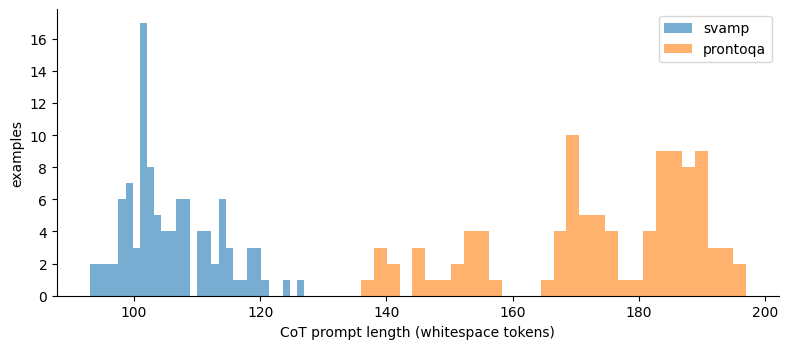

,min,median,mean,max
dataset,,,,
svamp,93,104,106,127
prontoqa,136,176,174,197


In [13]:
stats = []
fig, ax = plt.subplots(figsize=(8, 3.6))
for key, df in data.items():
    # whitespace tokens: a rough proxy, real tokenisation runs on the GPU box
    lens = df[tpl.cot_col].str.split().str.len()
    stats.append({"dataset": key, "min": lens.min(), "median": int(lens.median()),
                  "mean": round(lens.mean()), "max": lens.max()})
    ax.hist(lens, bins=30, alpha=0.6, label=key)
ax.set_xlabel("CoT prompt length (whitespace tokens)")
ax.set_ylabel("examples"); ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

pd.DataFrame(stats).set_index("dataset")

## 7. ProntoQA: does difficulty actually scale with hops?

Hop count is the stratification key, so it needs to mean something. The proof
length recorded with each example should grow with it.

,examples,true_answers,median_proof_steps,median_prompt_words
hop,,,,
2,25,13,5.0,171
3,25,7,7.0,170
4,25,14,9.0,171
5,25,16,11.0,187


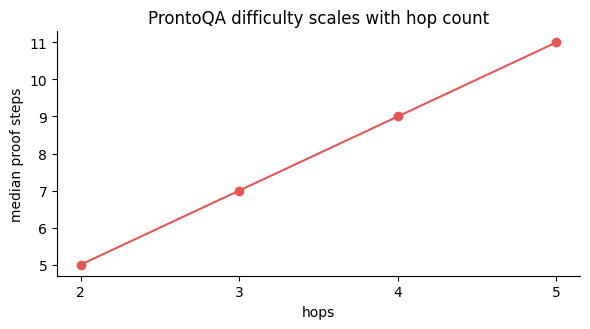

In [14]:
if "prontoqa" in data and "ChainOfThought" in data["prontoqa"].columns:
    p = data["prontoqa"].copy()
    p["proof_steps"] = p["ChainOfThought"].str.count(r"\.")
    summary = p.groupby("hop").agg(
        examples=("ID", "count"),
        true_answers=("Answer", lambda s: (s.astype(str) == "True").sum()),
        median_proof_steps=("proof_steps", "median"),
        median_prompt_words=(tpl.cot_col, lambda s: int(s.str.split().str.len().median())),
    )
    display(summary)

    fig, ax = plt.subplots(figsize=(6, 3.4))
    ax.plot(summary.index, summary["median_proof_steps"], "o-", color="#E45756")
    ax.set_xlabel("hops"); ax.set_ylabel("median proof steps")
    ax.set_title("ProntoQA difficulty scales with hop count")
    ax.set_xticks(summary.index); ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()
else:
    print("ProntoQA not loaded")

## 8. Browse

Sample rows in a table, for scanning rather than reading one at a time.

In [15]:
def browse(key, n=5, seed=0):
    task, df = get_task(key), data[key]
    cols = [task.id_column, *task.stratify_keys, task.answer_column, "PromptWithoutExample"]
    return df.sample(min(n, len(df)), random_state=seed)[cols].reset_index(drop=True)

browse("svamp")

,ID,OperationCount,Type,Answer,PromptWithoutExample
0,chal-76,1,Multiplication,2173,If each bag has 41 cookies and you had 53 bags of cookies How many cookies would you h...
1,chal-251,2,Addition,27,Winter is almost here and most animals are migrating to warmer countries. There are 3 ...
2,chal-290,1,Addition,745,After eating a hearty meal they went to see the Buckingham palace. There were 71 paint...
3,chal-969,2,Addition,38,Julia played tag with 13 kids on monday and 10 kids on tuesday. She played cards with ...
4,chal-503,2,Multiplication,5700,Each Ferris wheel in paradise park has 19 seats. Each seat in a Ferris wheel can hold ...


In [16]:
browse("prontoqa")

,ID,hop,Answer,PromptWithoutExample
0,3hop-example17,3,False,Brimpuses are fast. Brimpuses are rompuses. Brimpuses are tumpuses. Each rompus is liq...
1,5hop-example10,5,False,Grimpuses are not moderate. Grimpuses are gorpuses. Grimpuses are brimpuses. Gorpuses ...
2,2hop-example16,2,False,Each tumpus is small. Tumpuses are lempuses. Each yumpus is not angry. Each tumpus is ...
3,4hop-example13,4,False,Every grimpus is sour. Each grimpus is a sterpus. Each grimpus is a tumpus. Every ster...
4,5hop-example20,5,True,Every yumpus is not bitter. Each yumpus is a brimpus. Yumpuses are tumpuses. Brimpuses...


## 9. What happens next

The pools above are inputs, not the final experiment set. The pre-filter is the
first GPU job: it generates each candidate's CoT trace on all three models,
drops any that never reach the answer anchor, and keeps the intersection's
first 100. It also measures the true trace length, which replaces the estimate
in the compute plan.

```bash
python experiments/plan_compute.py --n 100      # workers + GPU-hour estimate
python experiments/run_patchings.py --model qwen2.5-0.5b --dataset svamp \
    --experiments normal random_margin random_jsd
```

`normal` scores margin and JSD from a single scan and writes one results file
per metric. The random controls read those for their head counts, so they run
after.